# Đọc dữ liệu

In [11]:
import pandas as pd

# Đường dẫn file CSV
file_path = r'../dataset/vsa_food_review/vsa_food_rv_train_cleaned.csv'

# Đọc file CSV
df_reviews = pd.read_csv(file_path, encoding='utf-8')

# Rename cột để thống nhất tên
df_reviews.rename(columns={
    'Comment': 'comment',
    'Rating': 'rating'
}, inplace=True)

# Kiểm tra dữ liệu
print("Kích thước dữ liệu:", df_reviews.shape)
print("\nCấu trúc DataFrame:")
print(df_reviews.info())
print("\nTop 5 dòng đầu:")
display(df_reviews.head())

print("\nThống kê Rating:")
print(df_reviews['rating'].value_counts())

Kích thước dữ liệu: (22761, 2)

Cấu trúc DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22761 entries, 0 to 22760
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   comment  22761 non-null  object
 1   rating   22761 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 355.8+ KB
None

Top 5 dòng đầu:


,comment,rating
0,Món ăn cực tệ,0
1,Mình thấy mọi người review tích cực nhưng thực...,0
2,Chắc với sinh viên thì ai cũng quen thuộc với ...,1
3,Nhiều hôm thèm lẩu riêu mà chỉ có một mình thì...,1
4,Không gian sạch sẽ.quán mới lên ra món hơi chậ...,1



Thống kê Rating:
rating
1    17292
0     5469
Name: count, dtype: int64


## Kiểm tra review trùng lặp

In [12]:
# --- KIỂM TRA VÀ XÓA TRÙNG LẶP BẢNG ĐÁNH GIÁ ---
print(f"Kích thước bảng Đánh Giá ban đầu: {df_reviews.shape[0]} dòng")

# Tìm các dòng trùng lặp dựa trên nội dung comment (vì file CSV chỉ có comment và rating)
is_duplicated_rev = df_reviews.duplicated(subset=['comment'], keep='first')
num_duplicates_rev = is_duplicated_rev.sum()

if num_duplicates_rev > 0:
    print(f"Phát hiện {num_duplicates_rev} đánh giá trùng lặp. Đang tiến hành xóa...")
    df_reviews = df_reviews.drop_duplicates(subset=['comment'], keep='first')
    df_reviews = df_reviews.reset_index(drop=True)
    print(f"Đã dọn dẹp xong. Kích thước mới: {df_reviews.shape[0]} dòng")
else:
    print("Không có dữ liệu trùng lặp.")

# Xem thử 5 dòng đầu sau khi kiểm tra trùng lặp
print("\n--- Dữ liệu sau kiểm tra trùng lặp ---")
print(f"Kích thước: {df_reviews.shape}")
display(df_reviews.head())

Kích thước bảng Đánh Giá ban đầu: 22761 dòng
Phát hiện 9867 đánh giá trùng lặp. Đang tiến hành xóa...
Đã dọn dẹp xong. Kích thước mới: 12894 dòng

--- Dữ liệu sau kiểm tra trùng lặp ---
Kích thước: (12894, 2)


,comment,rating
0,Món ăn cực tệ,0
1,Mình thấy mọi người review tích cực nhưng thực...,0
2,Chắc với sinh viên thì ai cũng quen thuộc với ...,1
3,Nhiều hôm thèm lẩu riêu mà chỉ có một mình thì...,1
4,Không gian sạch sẽ.quán mới lên ra món hơi chậ...,1


--- THÔNG KÊ SAU KHI LỌC ---
- Đã xóa: 470 review quá dài.
- Còn lại: 12424 review.
- Review dài nhất hiện tại: 256 từ.


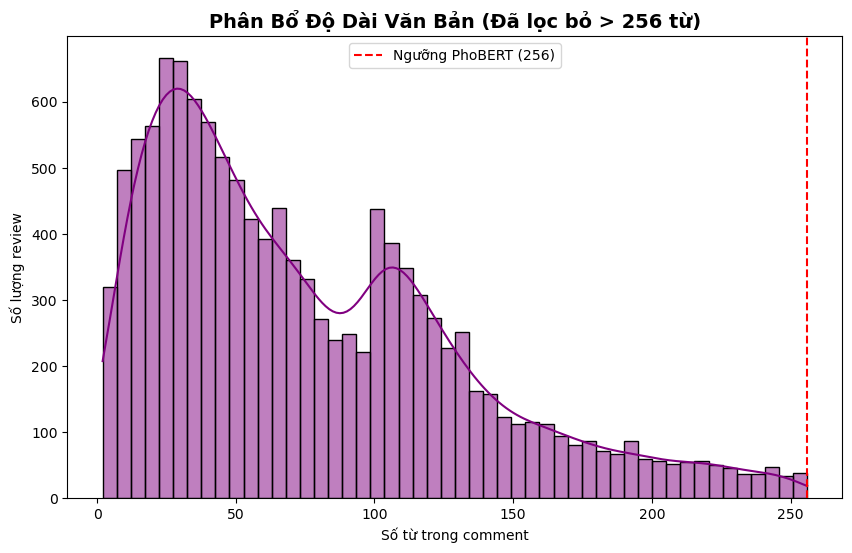

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tính toán cột word_count để lọc
df_reviews['word_count'] = df_reviews['comment'].apply(lambda x: len(str(x).split()))

# 2. Thực hiện lọc bỏ những dòng > 256 từ
initial_count = len(df_reviews)
df_reviews = df_reviews[df_reviews['word_count'] <= 256].reset_index(drop=True)

# 3. Tính toán lại báo cáo sau khi lọc
final_count = len(df_reviews)
removed_count = initial_count - final_count
max_len_after = df_reviews['word_count'].max()

# 4. Trực quan hóa kết quả sau lọc
plt.figure(figsize=(10, 6))
sns.histplot(df_reviews['word_count'], bins=50, kde=True, color='purple')
plt.axvline(x=256, color='red', linestyle='--', label='Ngưỡng PhoBERT (256)')
plt.title('Phân Bổ Độ Dài Văn Bản (Đã lọc bỏ > 256 từ)', fontsize=14, fontweight='bold')
plt.xlabel('Số từ trong comment')
plt.ylabel('Số lượng review')
plt.legend()

print(f"--- THÔNG KÊ SAU KHI LỌC ---")
print(f"- Đã xóa: {removed_count} review quá dài.")
print(f"- Còn lại: {final_count} review.")
print(f"- Review dài nhất hiện tại: {max_len_after} từ.")
plt.show()


In [14]:
import re
import pandas as pd
import unicodedata

# Tạo các thùng chứa (Log) để lưu kết quả truy vết cho từng lỗi
fixed_encoding = []
fixed_invisible = []
fixed_whitespace = []
fixed_non_alpha = []

def process_token(token):
    """
    Xử lý từng token (từ được phân tách bởi khoảng trắng).
    Quyết định giữ nguyên, làm sạch, hoặc xóa hoàn toàn.
    """
    # Giữ nguyên nếu token chỉ toàn chữ cái (không số, không ký tự đặc biệt)
    if not re.search(r'[\d\W]', token) or token == ',':
        return token

    # Tách dấu phẩy cuối token ra để xử lý riêng (VD: "50k," → core="50k", suffix=",")
    suffix = ''
    core = token
    if token.endswith(','):
        suffix = ','
        core = token[:-1]

    # Các pattern số hợp lệ → GIỮ LẠI
    if re.fullmatch(r'\d+[khp]', core):    # số+k / số+h / số+p : 50k, 22h, 30p
        return core + suffix
    if re.fullmatch(r'\d+/\d+', core):     # số/số                : 5/5, 1/2
        return core + suffix
    if re.fullmatch(r'\d+', core):         # số đứng độc lập      : 3 người, order 2 món
        return core + suffix

    # Còn lại: xóa ký tự đặc biệt + số, chỉ giữ chữ cái và dấu phẩy
    # VD: "3ng"→"ng", "<3"→"", "=))"→"", "covid19"→"covid", "24km"→"km"
    cleaned = re.sub(r'[^\w,]|_|\d', '', token)
    return cleaned if cleaned else ''

def track_and_clean(text):
    if pd.isna(text) or not isinstance(text, str):
        return ""

    step_0 = text

    # --- BƯỚC 0.5: Chuẩn hóa Unicode ---
    step_0 = unicodedata.normalize('NFC', step_0)

    # --- BƯỚC 1: Sửa lỗi mã hóa (Mojibake) ---
    step_1 = step_0
    try:
        decoded = step_0.encode('latin1').decode('utf-8')
        if decoded != step_0:
            step_1 = decoded
            fixed_encoding.append({"old": step_0, "new": step_1})
    except:
        pass

    # --- BƯỚC 2: Loại bỏ ký tự ẩn ---
    step_2 = re.sub(r'[\u200b\u200c\u200d\u200e\u200f\ufeff]+', '', step_1)
    step_2 = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', step_2)
    if step_2 != step_1:
        fixed_invisible.append({"old": repr(step_1), "new": repr(step_2)})

    # --- BƯỚC 3: Xử lý khoảng trắng lộn xộn & Xuống dòng ---
    step_3 = re.sub(r'[\r\n\t]+', ' ', step_2)
    step_3 = re.sub(r'\s+', ' ', step_3).strip()
    if step_3 != step_2:
        fixed_whitespace.append({"old": repr(step_2), "new": repr(step_3)})

    # --- BƯỚC 4: Chuyển toàn bộ về chữ thường ---
    step_4 = step_3.lower()

    # --- BƯỚC 5: XỬ LÝ DẤU CÂU & SỐ ---
    # Bước 5a: Thay dấu chấm → dấu phẩy (giữ lại điểm ngắt câu)
    step_5 = step_4.replace('.', ',')

    # Bước 5b: Xử lý từng token theo rule
    # Tách theo space → xử lý → ghép lại
    tokens = step_5.split(' ')
    processed = [process_token(t) for t in tokens]
    step_5 = ' '.join(t for t in processed if t)

    # Bước 5c: Dọn khoảng trắng lần cuối
    step_5 = re.sub(r'\s+', ' ', step_5).strip()

    if step_5 != step_4:
        fixed_non_alpha.append({"old": step_4, "new": step_5})

    return step_5

# ==========================================
# KHỞI CHẠY
# ==========================================
print(f"Đang quét dọn {len(df_reviews)} bình luận. Vui lòng chờ...")
initial_count = len(df_reviews)

df_reviews['comment'] = df_reviews['comment'].apply(track_and_clean)

# Xóa review rỗng sau khi làm sạch
df_reviews = df_reviews[df_reviews['comment'] != ''].reset_index(drop=True)
empty_removed_count = initial_count - len(df_reviews)

# ==========================================
# IN RA MINH CHỨNG (SHOW LOG)
# ==========================================
print("\n" + "="*80)
print(f"[BƯỚC 1] LUẬT ENCODING: Lôi ra ánh sáng {len(fixed_encoding)} review lỗi Font chữ")

print("\n" + "="*80)
print(f"[BƯỚC 2] KÝ TỰ TÀNG HÌNH: Đã bóc mẽ {len(fixed_invisible)} review")

print("\n" + "="*80)
print(f"[BƯỚC 3] KHOẢNG TRẮNG / XUỐNG DÒNG: Đã là phẳng {len(fixed_whitespace)} review bị ngắt dòng")

print("\n" + "="*80)
print(f"[BƯỚC 4 & 5] DỌN SẠCH DẤU CÂU & CHỮ SỐ: Đã chuẩn hóa {len(fixed_non_alpha)} review")
print(f"             GIỮ LẠI : số+k (50k) | số+h (22h) | số+p (30p) | số/số (5/5) | số đứng độc lập (3 người)")
print(f"             XÓA     : ký tự đặc biệt (<3 =)> ...) | số dính chữ (covid19, 3ng, 24km)")
print(f"             THAY    : dấu chấm '.' → dấu phẩy ','")
for i, item in enumerate(fixed_non_alpha[:5]):
    print(f"  ❌ [Gốc]: {item['old']}")
    print(f"  ✅ [Mới]: {item['new']}\n")

print("\n" + "="*80)
print(f"[BƯỚC CHUNG] DỮ LIỆU RỖNG: Đã phát hiện và xóa {empty_removed_count} review trống")
print(f"-> Tổng số review còn lại sau khi dọn dẹp: {len(df_reviews)}\n")

print("--- VÍ DỤ SAU TIỀN XỬ LÝ (5 REVIEW ĐẦU) ---")
display(df_reviews[['comment']].head(5))

Đang quét dọn 12424 bình luận. Vui lòng chờ...

[BƯỚC 1] LUẬT ENCODING: Lôi ra ánh sáng 0 review lỗi Font chữ

[BƯỚC 2] KÝ TỰ TÀNG HÌNH: Đã bóc mẽ 0 review

[BƯỚC 3] KHOẢNG TRẮNG / XUỐNG DÒNG: Đã là phẳng 0 review bị ngắt dòng

[BƯỚC 4 & 5] DỌN SẠCH DẤU CÂU & CHỮ SỐ: Đã chuẩn hóa 11238 review
             GIỮ LẠI : số+k (50k) | số+h (22h) | số+p (30p) | số/số (5/5) | số đứng độc lập (3 người)
             XÓA     : ký tự đặc biệt (<3 =)> ...) | số dính chữ (covid19, 3ng, 24km)
             THAY    : dấu chấm '.' → dấu phẩy ','
  ❌ [Gốc]: mình thấy mọi người review tích cực nhưng thực sự mình không thấy lẩu ở đây giống review. lẩu đắt và chán thực sự. never come back!
  ✅ [Mới]: mình thấy mọi người review tích cực nhưng thực sự mình không thấy lẩu ở đây giống review, lẩu đắt và chán thực sự, never come back

  ❌ [Gốc]: chắc với sinh viên thì ai cũng quen thuộc với lẩu nguyệt. cứ có dịp gì tụ tập đông đông là nhóm mình lại qua đây ăn. vừa ngon vừa rẻ. quán thì phải kéo dài từ vỉa hè đến 

,comment
0,món ăn cực tệ
1,mình thấy mọi người review tích cực nhưng thực...
2,chắc với sinh viên thì ai cũng quen thuộc với ...
3,nhiều hôm thèm lẩu riêu mà chỉ có một mình thì...
4,"không gian sạch sẽ,quán mới lên ra món hơi chậ..."


## Xử lý teencode (Kéo dài từ)

In [15]:
import re
import pandas as pd

def remove_elongation(text):
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Regex để tìm ký tự lặp lại 3 lần trở lên
    pattern = r'([a-zđáàãảạâấầẫẩậăắằẵẳặéèẽẻẹêếềễểệíìĩỉịóòõỏọôốồỗổộơớờỡởợúùũủụưứừữửựýỳỹỷỵ])\1{2,}'
    
    # Thay thế về 1 ký tự duy nhất
    text = re.sub(pattern, r'\1', text, flags=re.IGNORECASE)
    
    # === BƯỚC MỚI: XÓA DẤU PHẨY LIÊN TIẾP ===
    # Thay thế nhiều dấu phẩy liên tiếp (,,,) thành 1 dấu phẩy
    text = re.sub(r',+', ',', text)
    
    # Chuẩn hóa khoảng trắng xung quanh dấu phẩy (tránh " , , ," → " , ")
    text = re.sub(r'\s*,\s*', ', ', text)
    
    # Dọn dẹp khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Lưu cột gốc để so sánh
df_reviews['comment_old'] = df_reviews['comment']

print("Đang dọn dẹp các ký tự bị kéo dài (VD: ngonnnn -> ngon)...\n")
print("Đang xóa dấu phẩy liên tiếp (VD: tầm trung , , , mới → tầm trung , mới)...\n")
df_reviews['comment'] = df_reviews['comment'].apply(remove_elongation)

# Thống kê kết quả
changed_rows = (df_reviews['comment'] != df_reviews['comment_old']).sum()
print(f"--- THỰC HIỆN XONG ---")
print(f"Tổng số bình luận bị thay đổi: {changed_rows} dòng")

if changed_rows > 0:
    # Hiển thị ví dụ trước/sau
    changed_df = df_reviews[df_reviews['comment'] != df_reviews['comment_old']]
    print(f"\n--- {min(3, len(changed_df))} VÍ DỤ TRƯỚC/SAU ---")
    for idx, (before, after) in enumerate(zip(changed_df['comment_old'].head(3), changed_df['comment'].head(3))):
        print(f"\n{idx+1}. Trước: {before[:200]}...")
        print(f"   Sau:   {after[:200]}...")
else:
    print("✅ Dữ liệu đã sạch!")

# Xóa cột tạm
df_reviews = df_reviews.drop(columns=['comment_old'])

# Hiển thị sample
print(f"\n--- 5 DÒNG ĐẦU SAU XỬ LÝ ---")
display(df_reviews[['comment', 'rating']].head())

Đang dọn dẹp các ký tự bị kéo dài (VD: ngonnnn -> ngon)...

Đang xóa dấu phẩy liên tiếp (VD: tầm trung , , , mới → tầm trung , mới)...

--- THỰC HIỆN XONG ---
Tổng số bình luận bị thay đổi: 3800 dòng

--- 3 VÍ DỤ TRƯỚC/SAU ---

1. Trước: chắc với sinh viên thì ai cũng quen thuộc với lẩu nguyệt, cứ có dịp gì tụ tập đông đông là nhóm mình lại qua đây ăn, vừa ngon vừa rẻ, quán thì phải kéo dài từ vỉa hè đến cả trong ngõ 106, có cả ngồi d...
   Sau:   chắc với sinh viên thì ai cũng quen thuộc với lẩu nguyệt, cứ có dịp gì tụ tập đông đông là nhóm mình lại qua đây ăn, vừa ngon vừa rẻ, quán thì phải kéo dài từ vỉa hè đến cả trong ngõ 106, có cả ngồi d...

2. Trước: không gian sạch sẽ,quán mới lên ra món hơi chậm,p chờ cũng ko lâu lắm,nhưng đồ đều nóng thơm lừng,nhiều nữa chứ,...
   Sau:   không gian sạch sẽ, quán mới lên ra món hơi chậm, p chờ cũng ko lâu lắm, nhưng đồ đều nóng thơm lừng, nhiều nữa chứ,...

3. Trước: lang thang với cái bụng đói,đứng chờ tàu thì ngó thấy,quay xe đi vào,lúc đầu

,comment,rating
0,món ăn cực tệ,0
1,mình thấy mọi người review tích cực nhưng thực...,0
2,chắc với sinh viên thì ai cũng quen thuộc với ...,1
3,nhiều hôm thèm lẩu riêu mà chỉ có một mình thì...,1
4,"không gian sạch sẽ, quán mới lên ra món hơi ch...",1


## Chuẩn hóa Teencode, Viết tắt

In [16]:
import pandas as pd
import re
import os

# ============================================================
# BƯỚC 1: TỪ ĐIỂN VIẾT TẮT / TEENCODE THỦ CÔNG
# ============================================================
# ============================================================
# BƯỚC 1: TỪ ĐIỂN VIẾT TẮT / TEENCODE / TIẾNG ANH (CẬP NHẬT)
# ============================================================
ABBREV_DICT = {
    # 1. TỪ PHỦ ĐỊNH / TỪ NỐI / TRẠNG TỪ
    "ko": "không", "k": "không", "kh": "không", "kg": "không", "kog": "không", 
    "khg": "không", "hong": "không", "hok": "không", "khom": "không", "khong": "không",
    "vs": "với", "cx": "cũng", "cg": "cũng", "cũg": "cũng", "cux": "cũng", 
    "trc": "trước", "truoc": "trước", "th": "thì",
    "lun": "luôn", "luon": "luôn", "luonn": "luôn", "luônn": "luôn",
    "r": "rồi", "rùi": "rồi", "rui": "rồi", "ròi": "rồi", "xog": "xong",
    "z": "vậy", "vz": "vậy", "zậy": "vậy", "zui": "vui", "dzui": "vui",
    "j": "gì", "qá": "quá", "qa": "quá", "quáa": "quá", "rât": "rất",
    "nhma": "nhưng mà", "nma": "nhưng mà", "nhg": "nhưng",
    "nchung": "nói chung", "nc": "nói chung", "nch": "nói chung",
    "bt": "bình thường", "bth": "bình thường", "bthg": "bình thường", "bthuong": "bình thường",
    "vc": "vô cùng", "vcl": "vô cùng", "vl": "vô cùng", "vch": "vô cùng",
    "ntn": "như thế nào", "ms": "mới",

    # 2. NGƯỜI / ĐẠI TỪ
    "nv": "nhân viên", "nvien": "nhân viên", "nvpv": "nhân viên phục vụ",
    "ng": "người", "ngta": "người ta", "ngừoi": "người", "nguoi": "người", "ngươ": "người",
    "mk": "mình", "mik": "mình", "tui": "tôi", "t": "tôi",
    "mn": "mọi người", "mng": "mọi người", "mnguoi": "mọi người",
    "bn": "bạn", "b": "bạn", "ae": "anh em", "ce": "chị em",
    "gd": "gia đình", "gđ": "gia đình", "gdinh": "gia đình",

    # 3. THUẬT NGỮ NHÀ HÀNG / DỊCH VỤ / TRẢI NGHIỆM
    "đc": "được", "dc": "được", "dk": "được", "đk": "được", "đươc": "được",
    "ql": "quản lý", "qly": "quản lý", "cskh": "chăm sóc khách hàng",
    "pv": "phục vụ", "pvu": "phục vụ", "phuc": "phục vụ",
    "kh": "khách hàng", # (tùy ngữ cảnh, có thể là 'không')
    "ch": "cửa hàng", "nh": "nhà hàng", "cn": "chi nhánh",
    "đt": "điện thoại", "dt": "điện thoại",
    "ck": "chuyển khoản", "tt": "thanh toán", "vat": "thuế VAT",
    "km": "khuyến mãi", "sp": "sản phẩm", "cty": "công ty",
    "đb": "đặc biệt", "dbiet": "đặc biệt",
    "kgian": "không gian", "csvc": "cơ sở vật chất",
    "dth": "dễ thương", "dthw": "dễ thương", "dthuong": "dễ thương",
    "mlem": "ngon", "thik": "thích", "thix": "thích",
    "hssv": "học sinh sinh viên", "hs": "học sinh", "sv": "sinh viên",
    "sn": "sinh nhật",
    "thit": "thịt", "nuoc": "nước", "nhiet": "nhiệt", "thuong": "thương",

    # 4. THỜI GIAN / ĐỊA DANH
    "hnay": "hôm nay", "hm": "hôm nay",
    "hqua": "hôm qua", "hqa": "hôm qua",
    "tgian": "thời gian", "tg": "thời gian",
    "hcm": "Hồ Chí Minh", "tphcm": "TP. Hồ Chí Minh",
    "hn": "Hà Nội", "sg": "Sài Gòn", "tp": "thành phố",
    "vn": "Việt Nam", "hq": "Hàn Quốc",
    "pmh": "Phú Mỹ Hưng", "svh": "Sư Vạn Hạnh",

    # 5. SỬA LỖI CHÍNH TẢ / CẢM THÁN KÉO DÀI
    "ok": "ok", "oke": "ok", "okela": "ok", "okila": "ok", "okey": "ok", "oki": "ok",
    "ngonn": "ngon", "lắmm": "lắm",
    "nhaa": "nha", "ạa": "ạ", "ạaa": "ạ", "nhee": "nhé",
    "tr": "trời", "chời": "trời",
    "haha": "haha", "hihi": "hihi", "huhu": "huhu",

    # 6. TIẾNG ANH: VIẾT TẮT / SAI CHÍNH TẢ -> TIẾNG ANH CHUẨN
    "rcm": "recommend", "rec": "recommend", "recomend": "recommend", "reccomend": "recommend",
    "ord": "order", "oder": "order",
    "rv": "review",
    "cmt": "comment", "rep": "reply",
    "fb": "facebook", "ig": "instagram", "ib": "inbox",
    "wf": "wifi", "cf": "cafe",
    "stt": "status", "app": "application",
    "toping": "topping", "toppings": "topping",
    "dishes": "dish", "noodles": "noodle", "prices": "price", "services": "service",
    "takecare": "take care", "chilli": "chili",

    # 7. TIẾNG ANH & NGOẠI LAI (CHUẨN HÓA MỘT SỐ TÊN GỌI)
    "panchan": "banchan", "pancha": "banchan",
    "kimbab": "kimbap",
    "tokbokki": "tokbokki", "tok": "tokbokki", "tteokbokki": "tokbokki", "tobokki": "tokbokki",
    "phomai": "phô mai",
    "vnd": "VNĐ", "vnđ": "VNĐ",
    "nvs": "WC", "wc": "WC",
    "qr": "QR",

    
}

# BƯỚC 2: HÀM NORMALIZE VIẾT TẮT

def normalize_text(text: str) -> str:
    """Thay thế từ viết tắt bằng từ đầy đủ dựa theo ABBREV_DICT."""
    if not isinstance(text, str):
        return ""
        
    words = text.split()
    normalized = []
    for w in words:
        w_lower = w.lower()
        if w_lower in ABBREV_DICT:
            normalized.append(ABBREV_DICT[w_lower])
        else:
            normalized.append(w)
    return " ".join(normalized)

# BƯỚC 3: ÁP DỤNG THAY ĐỔI

# Giả sử bạn đang có dataframe `df_reviews`
# Xóa các dòng comment bị rỗng (NaN)
df_reviews = df_reviews.dropna(subset=['comment']).copy()

# (Tuỳ chọn) Nếu bạn muốn ghi đè trực tiếp lên cột comment cũ, sử dụng lệnh dưới đây:
df_reviews['comment'] = df_reviews['comment'].apply(normalize_text)

print("Đã hoàn thành việc quy đổi từ viết tắt!")

Đã hoàn thành việc quy đổi từ viết tắt!


## 2. Tần suất xuất hiện N-grams (Từ vựng)

Số lượng review rating 0 (Tiêu cực (0)): 3169
Số lượng review rating 1 (Tích cực (1)): 9255


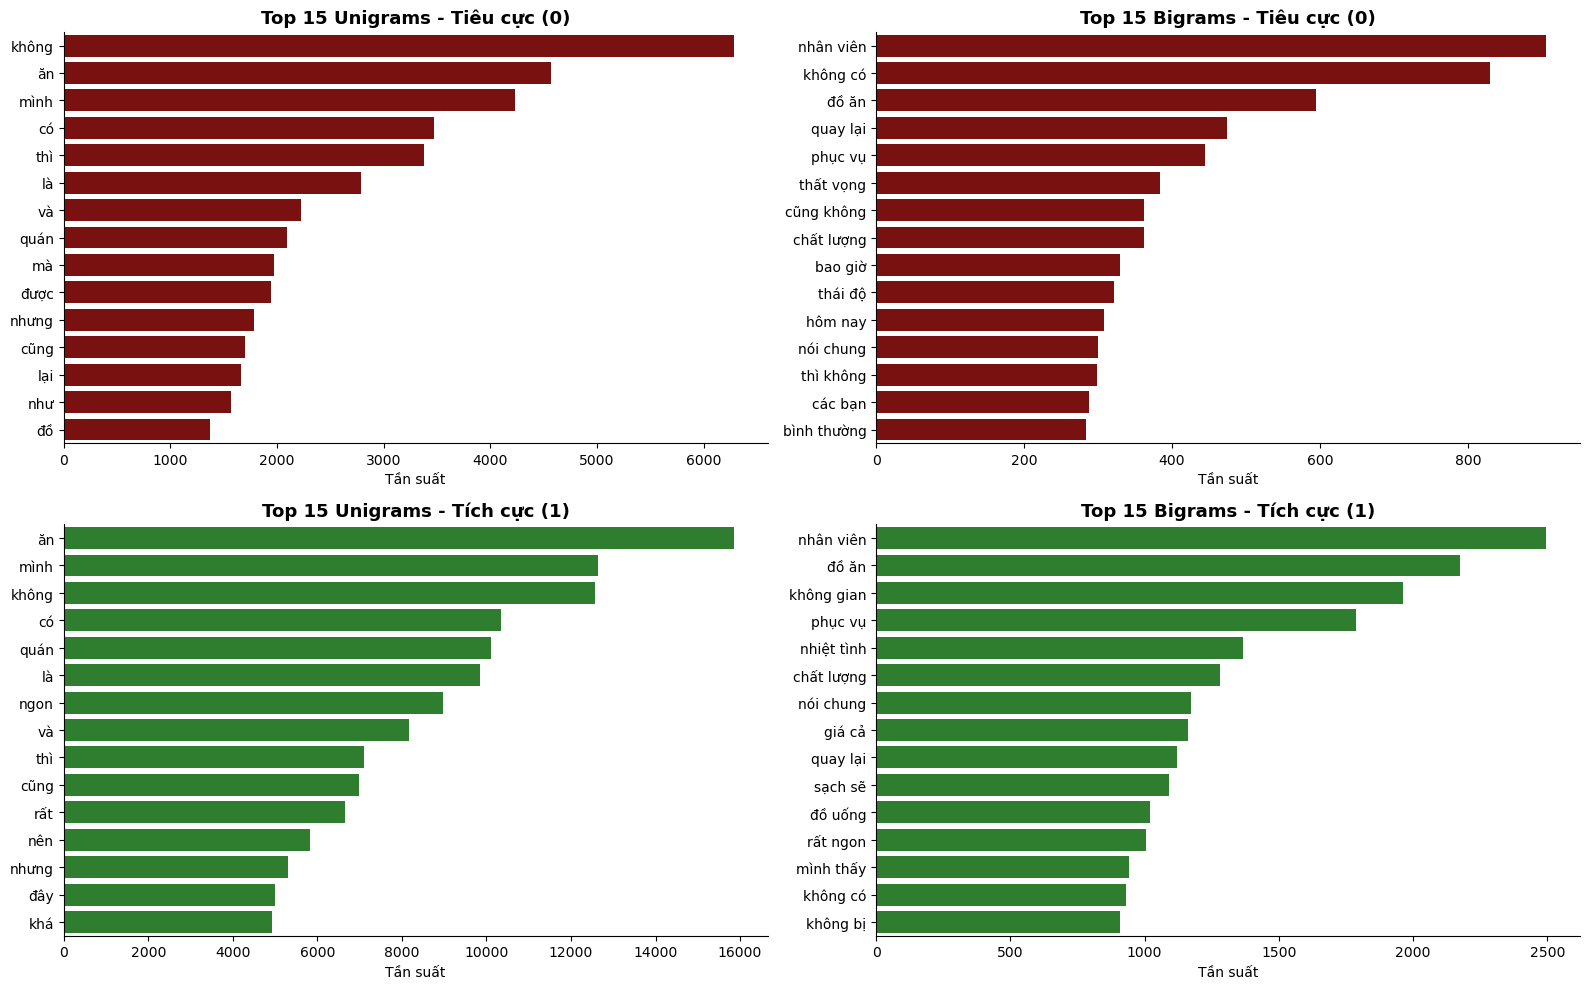

✅ Đã xuất toàn bộ N-grams (Unigrams + Bigrams) tại: ../dataset/preprocessed\all_ngrams_by_rating.csv
   Tổng số dòng: 275,938



In [17]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Hàm phụ trợ để trích xuất N-gram từ một tập văn bản
def get_top_ngrams(corpus, n=None, ngram_range=(1, 1)):
    if len(corpus) == 0: 
        return []
    
    # Khởi tạo CountVectorizer
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    
    # Lấy danh sách từ và tần suất
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    # Sắp xếp giảm dần theo tần suất
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    
    # Nếu n=None, trả về toàn bộ danh sách
    return words_freq if n is None else words_freq[:n]

# Hàm vẽ biểu đồ (Trực quan hóa)
def plot_ngrams(ax, data, title, color):
    if not data: # Bỏ qua nếu không có dữ liệu
        return
    df_ngrams = pd.DataFrame(data, columns=['N-gram', 'Tần suất'])
    sns.barplot(x='Tần suất', y='N-gram', data=df_ngrams, ax=ax, color=color)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('Tần suất')
    ax.set_ylabel('')

# Tạo không gian vẽ 2 biểu đồ (2 hàng x 2 cột cho Unigrams và Bigrams)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Dải màu: Tiêu cực (Đỏ) và Tích cực (Xanh)
colors = ['darkred', 'forestgreen']
rating_labels = {0: 'Tiêu cực (0)', 1: 'Tích cực (1)'}

# --- THÚNG CHỨA ĐỂ LƯU TOÀN BỘ DỮ LIỆU N-GRAMS ---
all_ngrams_data = []
unigrams_data = []  # Riêng cho 1-grams

# Duyệt qua từng mức rating (chỉ 0 và 1)
for i, rating in enumerate([0, 1]):
    # Lấy dữ liệu theo rating
    corpus = df_reviews[df_reviews['rating'] == rating]['comment'].dropna()
    print(f"Số lượng review rating {rating} ({rating_labels[rating]}): {len(corpus)}")
    
    # RÚT TRÍCH TOÀN BỘ N-GRAMS (Không đưa giới hạn n vào)
    all_unigrams = get_top_ngrams(corpus, n=None, ngram_range=(1, 1))
    all_bigrams = get_top_ngrams(corpus, n=None, ngram_range=(2, 2))
    
    # Lưu vào danh sách tổng
    for ngram, freq in all_unigrams:
        all_ngrams_data.append({'Rating': rating, 'Loại': 'Unigram', 'N-gram': ngram, 'Tần suất': freq})
        unigrams_data.append({'Rating': rating, 'N-gram': ngram, 'Tần suất': freq})
        
    for ngram, freq in all_bigrams:
        all_ngrams_data.append({'Rating': rating, 'Loại': 'Bigram', 'N-gram': ngram, 'Tần suất': freq})
    
    # Vẽ biểu đồ (Cắt Top 15 để hình vẽ không bị quá tải)
    plot_ngrams(axes[i, 0], all_unigrams[:15], f'Top 15 Unigrams - {rating_labels[rating]}', colors[i])
    plot_ngrams(axes[i, 1], all_bigrams[:15],  f'Top 15 Bigrams - {rating_labels[rating]}', colors[i])

# Căn chỉnh layout cho đẹp
plt.tight_layout()
sns.despine()
plt.show()

# ====================================================
# XUẤT DỮ LIỆU RA FILE DƯỚI DẠNG CSV
# ====================================================

# Đảm bảo thư mục lưu trữ đã tồn tại
save_dir = '../dataset/preprocessed'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 1. XUẤT TOÀN BỘ N-GRAMS (Unigrams + Bigrams)
df_all_ngrams = pd.DataFrame(all_ngrams_data)
all_ngrams_path = os.path.join(save_dir, 'all_ngrams_by_rating.csv')
df_all_ngrams.to_csv(all_ngrams_path, index=False, encoding='utf-8-sig')
print(f"✅ Đã xuất toàn bộ N-grams (Unigrams + Bigrams) tại: {all_ngrams_path}")
print(f"   Tổng số dòng: {len(df_all_ngrams):,}\n")

# 2. XUẤT RIÊNG CHỈ 1-GRAMS (Unigrams)
# df_unigrams = pd.DataFrame(unigrams_data)
# unigrams_path = os.path.join(save_dir, 'unigrams_by_rating.csv')
#df_unigrams.to_csv(unigrams_path, index=False, encoding='utf-8-sig')
# print(f"✅ Đã xuất riêng 1-grams tại: {unigrams_path}")
# print(f"   Tổng số dòng: {len(df_unigrams):,}\n")

# Thống kê chi tiết
# print("--- THỐNG KÊ 1-GRAMS THEO RATING ---")
# for rating in [0, 1]:
#    count = len(df_unigrams[df_unigrams['Rating'] == rating])
#    print(f"Rating {rating} ({rating_labels[rating]}): {count} n-grams")

# print("\n--- TOP 10 1-GRAMS PHỔ BIẾN NHẤT (Tất cả) ---")
# print(df_unigrams.nlargest(10, 'Tần suất'))

# print("\n--- TOP 5 1-GRAMS TIÊU Cực (Rating=0) ---")
# print(df_unigrams[df_unigrams['Rating'] == 0].nlargest(5, 'Tần suất'))

# print("\n--- TOP 5 1-GRAMS TÍCH CỰC (Rating=1) ---")
# print(df_unigrams[df_unigrams['Rating'] == 1].nlargest(5, 'Tần suất'))

In [18]:
import pandas as pd
import re

# ============================================================
# BƯỚC 1: ĐỌC FILE TỪ ĐIỂN
# ============================================================
dict_path = '../dataset/preprocessed/tu_can_xu_ly_thu_cong_da_dich_vsa.csv' 

try:
    df_dict = pd.read_csv(dict_path, encoding='utf-8')
    print(f"✅ Đã đọc thành công file từ điển với {len(df_dict)} từ.\n")
    
    # Kiểm tra cột có tồn tại không
    if 'dịch' not in df_dict.columns:
        print(f"❌ Lỗi: File không có cột 'Dịch'. Các cột hiện có: {list(df_dict.columns)}")
        abbreviation_mapping = {}
    else:
        # Chỉ lấy các từ có tồn tại giá trị ở cột 'Dịch' (loại bỏ hàng trống)
        df_dict_valid = df_dict.dropna(subset=['dịch'])
        df_dict_valid = df_dict_valid[df_dict_valid['dịch'].astype(str).str.strip() != '']
        
        # CHUYỂN THÀNH DICTIONARY
        abbreviation_mapping = dict(zip(
            df_dict_valid['N-gram'].astype(str).str.lower().str.strip(), 
            df_dict_valid['dịch'].astype(str).str.lower().str.strip()
        ))
        
        print(f"📊 Thống kê:")
        print(f"   - Tổng từ trong file: {len(df_dict)}")
        print(f"   - Từ đã điền (có cột Dịch): {len(df_dict_valid)}")
        print(f"   - Từ trong từ điển hoạt động: {len(abbreviation_mapping)}\n")
    
except FileNotFoundError:
    print(f"❌ Không tìm thấy file: {dict_path}")
    abbreviation_mapping = {}
except Exception as e:
    print(f"❌ Lỗi khi đọc file: {e}")
    abbreviation_mapping = {}

# ============================================================
# BƯỚC 2: HÀM THAY THẾ TỪ (CẬP NHẬT)
# ============================================================
def replace_words_from_dict(text):
    """Thay thế từ viết tắt/slang bằng từ đầy đủ."""
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Tách thành các từ
    words = text.split()
    replaced_words = []
    
    for word in words:
        word_lower = word.lower().strip()
        # Kiểm tra từ này có trong từ điển không
        if word_lower in abbreviation_mapping:
            replaced_words.append(abbreviation_mapping[word_lower])
        else:
            replaced_words.append(word)  # Giữ nguyên từ cũ
    
    return " ".join(replaced_words)

# ============================================================
# BƯỚC 3: ÁP DỤNG THAY ĐỔI
# ============================================================
if len(abbreviation_mapping) > 0:
    print("🔄 Đang thay thế từ viết tắt trong dataset...\n")
    
    # Đếm số từ được thay thế
    before_texts = df_reviews['comment'].copy()
    df_reviews['comment'] = df_reviews['comment'].apply(replace_words_from_dict)
    
    # Kiểm tra xem có từ nào được thay thế không
    changed_count = (before_texts != df_reviews['comment']).sum()
    print(f"✅ Cập nhật hoàn tất!")
    print(f"   - Số review bị thay đổi: {changed_count:,} / {len(df_reviews):,}")
    print(f"   - Tỷ lệ thay đổi: {(changed_count/len(df_reviews)*100):.2f}%\n")
    
    # Hiển thị ví dụ
    changed_reviews = df_reviews[before_texts != df_reviews['comment']]
    if len(changed_reviews) > 0:
        print("--- 3 VÍ DỤ REVIEW BỊ THAY ĐỔI ---")
        for idx, (old, new) in enumerate(zip(before_texts[before_texts != df_reviews['comment']].head(3), 
                                              changed_reviews['comment'].head(3)), 1):
            print(f"\n{idx}. Trước: {old[:100]}...")
            print(f"   Sau:   {new[:100]}...")
else:
    print("⚠️ Từ điển trống hoặc không được tải. Bỏ qua bước thay thế.")

# ============================================================
# BƯỚC 4: XEM THỐNG KÊ TỪ ĐIỂN
# ============================================================
if len(abbreviation_mapping) > 0:
    print("\n--- TOP 10 TỪ ĐƯỢC THAY THẾ (THEO TẦN SUẤT) ---")
    top_replacements = []
    for abbr, full in list(abbreviation_mapping.items())[:10]:
        print(f"  '{abbr}' → '{full}'")

✅ Đã đọc thành công file từ điển với 6767 từ.

❌ Lỗi: File không có cột 'Dịch'. Các cột hiện có: ['N-gram', 'Dịch', 'Tần suất']
⚠️ Từ điển trống hoặc không được tải. Bỏ qua bước thay thế.


In [19]:
# !pip install langdetect
from langdetect import detect, LangDetectException

# ==========================================
# PHẦN LỌC NGÔN NGỮ (CHỈ GIỮ TIẾNG VIỆT VÀ TIẾNG ANH)
# ==========================================

def filter_language(text):
    if pd.isna(text) or text.strip() == "":
        return "unknown"
    try:
        # Nhận diện ngôn ngữ
        lang = detect(text)
        return lang
    except LangDetectException:
        # Các trường hợp lỗi (ví dụ chuỗi quá ngắn, toàn số, hoặc toàn icon)
        return "unknown"

print(f"\nBắt đầu lọc ngôn ngữ. Tổng số review hiện tại: {len(df_reviews)}")

# Tạo thêm một cột tạm 'language' để kiểm tra kết quả nhận diện
df_reviews['language'] = df_reviews['comment'].apply(filter_language)

# Chỉ giữ lại các review là 'vi' (Tiếng Việt) hoặc 'en' (Tiếng Anh)
df_valid_lang = df_reviews[df_reviews['language'].isin(['vi', 'en'])].copy()

# Xóa cột 'language' đi cho Dataframe gọn gàng
df_valid_lang = df_valid_lang.drop(columns=['language']).reset_index(drop=True)

# Tính số lượng review bị loại và cập nhật lại df_reviews
removed_lang_count = len(df_reviews) - len(df_valid_lang)
df_reviews = df_valid_lang

print(f"Đã loại bỏ {removed_lang_count} review không phải Tiếng Việt hoặc Tiếng Anh (hoặc quá ngắn không thể nhận diện).")
print(f"-> Tổng số review còn lại: {len(df_reviews)}")


Bắt đầu lọc ngôn ngữ. Tổng số review hiện tại: 12424
Đã loại bỏ 13 review không phải Tiếng Việt hoặc Tiếng Anh (hoặc quá ngắn không thể nhận diện).
-> Tổng số review còn lại: 12411


In [20]:
import pandas as pd
import os

# ============================================================
# BƯỚC 1: KIỂM TRA VÀ DỌNS SÁCH DỮ LIỆU
# ============================================================
print("Kiểm tra các cột trong dữ liệu...")
print(f"Các cột hiện có: {list(df_reviews.columns)}\n")

# Xóa cột 'word_count' vì không cần thiết
if 'word_count' in df_reviews.columns:
    df_reviews = df_reviews.drop(columns=['word_count'])
    print("✅ Đã xóa cột 'word_count'\n")

# ============================================================
# BƯỚC 2: ĐỊNH NGHĨA HÀM GÁN NHÃN
# ============================================================
def assign_label(rating):
    """Gán nhãn sentiment dựa trên rating"""
    if pd.isna(rating):
        return None
    
    rating = int(rating)
    
    if rating in [4, 5]:
        return 1  # Tích cực
    elif rating == 3:
        return 2  # Trung tính
    elif rating in [0, 1, 2]:
        return 0  # Tiêu cực
    else:
        return None  # Rating không hợp lệ

# ============================================================
# BƯỚC 3: TẠO DATAFRAME CUỐI CÙNG (CHỈ 2 CỘT)
# ============================================================
try:
    # Tạo DataFrame với chỉ 2 cột: review và labels
    reviews_final = pd.DataFrame({
        'review': df_reviews['comment'],
        'labels': df_reviews['rating'].apply(assign_label)
    })
    
    # Lọc bỏ các trường hợp lỗi (không có label)
    initial_count = len(reviews_final)
    reviews_final = reviews_final.dropna(subset=['labels'])
    removed_count = initial_count - len(reviews_final)
    
    if removed_count > 0:
        print(f"⚠️ Đã xóa {removed_count} review không có label hợp lệ.\n")
    
    # Chuyển nhãn thành số nguyên
    reviews_final['labels'] = reviews_final['labels'].astype(int)
    
except KeyError as e:
    print(f"❌ Lỗi: Cột {e} không tồn tại trong dữ liệu!")
    print(f"Các cột hiện có: {list(df_reviews.columns)}")
    reviews_final = None
except Exception as e:
    print(f"❌ Lỗi khi tạo DataFrame: {e}")
    reviews_final = None

# ============================================================
# BƯỚC 4: LƯU DỮ LIỆU RA FILE CSV
# ============================================================
if reviews_final is not None:
    save_dir = '../dataset/preprocessed'
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    final_output_path = os.path.join(save_dir, 'reviews_final_vsa.csv')
    reviews_final.to_csv(final_output_path, index=False, encoding='utf-8-sig')
    
    print(f"✅ Đã lưu file thành công tại: {final_output_path}")
    print(f"📊 Kích thước bộ dữ liệu: {reviews_final.shape[0]:,} dòng × {reviews_final.shape[1]} cột (review, labels)\n")
    
    # ============================================================
    # BƯỚC 5: THỐNG KÊ CHI TIẾT
    # ============================================================
    print("--- PHÂN PHỐI NHÃN (LABELS) ---")
    print("0: Tiêu cực | 1: Tích cực | 2: Trung tính\n")
    
    label_counts = reviews_final['labels'].value_counts().sort_index()
    for label, count in label_counts.items():
        label_name = {0: "Tiêu cực", 1: "Tích cực", 2: "Trung tính"}.get(label, "Unknown")
        percentage = (count / len(reviews_final)) * 100
        print(f"  Label {label} ({label_name}): {count:,} ({percentage:.2f}%)")
    
    print("\n--- CẤU TRÚC DỮ LIỆU ---")
    print(reviews_final.info())
    
    print("\n--- 5 DÒNG ĐẦU TIÊN (VÍ DỤ) ---")
    display(reviews_final.head())
    
    print("\n--- 5 DÒNG CUỐI CÙNG (VÍ DỤ) ---")
    display(reviews_final.tail())
    
else:
    print("❌ Không thể tạo file output. Vui lòng kiểm tra dữ liệu!")

Kiểm tra các cột trong dữ liệu...
Các cột hiện có: ['comment', 'rating', 'word_count']

✅ Đã xóa cột 'word_count'

✅ Đã lưu file thành công tại: ../dataset/preprocessed\reviews_final_vsa.csv
📊 Kích thước bộ dữ liệu: 12,411 dòng × 2 cột (review, labels)

--- PHÂN PHỐI NHÃN (LABELS) ---
0: Tiêu cực | 1: Tích cực | 2: Trung tính

  Label 0 (Tiêu cực): 12,411 (100.00%)

--- CẤU TRÚC DỮ LIỆU ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12411 entries, 0 to 12410
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  12411 non-null  object
 1   labels  12411 non-null  int32 
dtypes: int32(1), object(1)
memory usage: 145.6+ KB
None

--- 5 DÒNG ĐẦU TIÊN (VÍ DỤ) ---


,review,labels
0,món ăn cực tệ,0
1,mình thấy mọi người review tích cực nhưng thực...,0
2,chắc với sinh viên thì ai cũng quen thuộc với ...,0
3,nhiều hôm thèm lẩu riêu mà chỉ có một mình thì...,0
4,"không gian sạch sẽ, quán mới lên ra món hơi ch...",0



--- 5 DÒNG CUỐI CÙNG (VÍ DỤ) ---


,review,labels
12406,tính ra bánh khá đắt so với bánh mì truyền thố...,0
12407,"mình gọi chè thái caramen, bạn mình gọi chè xu...",0
12408,nghe đồn nem tai bà hồng nổi lắm thì phải chị ...,0
12409,"lẩu ếch rất ngon, gọi nồi lẩu ếch to nước ngon...",0
12410,mới qua ăn thử về review pizza thơm béo phô ma...,0
